In [1]:
import pandas as pd
from urllib.request import urlopen
import numpy as np
from lxml import etree
import re

path = "/home/yamane/transformerCPI/data/classAByProtein/"

file_path = "/data/yamane/GPCRclassAData/"
fle_name = ["chemblSmiles.csv","classA_ligand_binary_202110.csv","id2seq.csv"]

smiles_df = pd.read_csv(file_path+fle_name[0]).drop("Unnamed: 0",axis = 1)
origin_df = pd.read_csv("origin.csv").drop("Unnamed: 0",axis = 1)
seq_df = pd.read_csv(file_path+fle_name[2]).drop("Unnamed: 0",axis = 1)

# uniprotからhelixの場所をとってくる
P47746 だけ無理

In [2]:
# print("interaction : ",len(origin_df))
# print("protein_num : ",len(set(origin_df["UniProt ID"].to_list())))
# print("ligand_num : ",len(set(origin_df["Database Ligand ID"].to_list())))

# uniIds = seq_df["UniProt ID"].to_list()
# resultDatas = []
# for uniId in uniIds:
#   url = "https://www.uniprot.org/uniprot/" + uniId + ".xml"
#   f = urlopen(url)
#   xml = f.read()
#   root = etree.fromstring(xml)

#   sequence = root.find('./entry/sequence', root.nsmap)#sequenceの取得
#   datas = xml.decode().split("\n")
#   for index,data in enumerate(datas):
#     if data[:36] == "<feature type=\"transmembrane region\"":
#       namePattern = r'.*?(Name=\d)'
#       nameResult = re.match(namePattern,data)
#       #print(index,nameResult.group(1),datas[index+2],datas[index+3])
#       try:
#         resultDatas.append([uniId,sequence.text ,nameResult.group(1),datas[index+2],datas[index+3]])
#       except:
#         print(uniId,data,datas[index+2],datas[index+3])
#         break

#hhelix_side_df = pd.DataFrame(resultDatas,columns = ["id","seq","hname","begin","end"])
#hhelix_side_df.to_csv("/data/yamane/GPCRclassAData/helix_pos.csv")

# その他諸々
- P47746の回収
- begin , endのint変換
- 該当箇所のsequenceの抽出
- 名前の変更

original : /data/yamane/GPCRclassAData/helix_pos.csv

sliced : /data/yamane/GPCRclassAData/sliced_helix_pos_all.csv


In [3]:
helixPos = pd.read_csv("/data/yamane/GPCRclassAData/helix_pos.csv",index_col=0)

In [4]:
# uniId = "P47746"
# url = "https://www.uniprot.org/uniprot/" + uniId + ".xml"
# f = urlopen(url)
# xml = f.read()
# root = etree.fromstring(xml)
# sequence = root.find('./entry/sequence', root.nsmap)

# datas = xml.decode().split("\n")
# hname = 0
# for index,data in enumerate(datas):
#   if data[:36] == "<feature type=\"transmembrane region\"":
#     hname += 1
#     name = "Name="+str(hname)
#     #print(index,name,datas[index+2],datas[index+3])
#     helixPos = helixPos.append({"id":uniId,"seq":sequence.text,"hname":name,"begin":datas[index+2],"end":datas[index+3]},ignore_index=True)

# def transfer_number(strings):
#   result = strings.split("\"")[1]
#   return int(result)

# def transfer_name(strings):
#   return "h_"+strings.split("=")[1]

# helixPos["begin"] = helixPos["begin"].apply(transfer_number)
# helixPos["end"] = helixPos["end"].apply(transfer_number)
# helixPos["hname"] = helixPos["hname"].apply(transfer_name)

# sequence_sliced = []
# for i in range(len(helixPos)):
#   info = helixPos.iloc[i]
#   thiSeq = info["seq"][info["begin"]-1:info["end"]]
#   sequence_sliced.append(thiSeq)

# helixPos["sliced_Sequence"] = sequence_sliced
#helixPos.to_csv("/data/yamane/GPCRclassAData/sliced_helix_pos_all.csv")


In [5]:
helixPos = pd.read_csv("/data/yamane/GPCRclassAData/sliced_helix_pos_all.csv",index_col=0)

In [6]:
helixPos[helixPos["id"] == "P21917"]["seq"][2226 ]

'MGNRSTADADGLLAGRGPAAGASAGASAGLAGQGAAALVGGVLLIGAVLAGNSLVCVSVATERALQTPTNSFIVSLAAADLLLALLVLPLFVYSEVQGGAWLLSPRLCDALMAMDVMLCTASIFNLCAISVDRFVAVAVPLRYNRQGGSRRQLLLIGATWLLSAAVAAPVLCGLNDVRGRDPAVCRLEDRDYVVYSSVCSFFLPCPLMLLLYWATFRGLQRWEVARRAKLHGRAPRRPSGPGPPSPTPPAPRLPQDPCGPDCAPPAPGLPRGPCGPDCAPAAPSLPQDPCGPDCAPPAPGLPPDPCGSNCAPPDAVRAAALPPQTPPQTRRRRRAKITGRERKAMRVLPVVVGAFLLCWTPFFVVHITQALCPACSVPPRLVSAVTWLGYVNSALNPVIYTVFNAEFRNVFRKALRACC'

In [7]:
helix_concat = ""
list_ = helixPos[helixPos["id"] == "P21917"]["sliced_Sequence"].values.tolist()
print("".join(list_))

file_path = "/data/yamane/GPCRclassAData/"
fle_name = ["chemblSmiles.csv","classA_ligand_binary_202110.csv","SHP_for_featurize_concat.csv"]

smiles_df = pd.read_csv(file_path+fle_name[0]).drop("Unnamed: 0",axis = 1)
origin_df = pd.read_csv(file_path+fle_name[1]).drop("Unnamed: 0",axis = 1)
seq_df = pd.read_csv(file_path+fle_name[2]).drop("Unnamed: 0",axis = 1)


LAGQGAAALVGGVLLIGAVLAFIVSLAAADLLLALLVLPLFVLMAMDVMLCTASIFNLCAISVLLLIGATWLLSAAVAAPVLCGVVYSSVCSFFLPCPLMLLLYWVLPVVVGAFLLCWTPFFVVHISAVTWLGYVNSALNPVIYTVF


In [8]:
origin_df[origin_df["UniProt ID"] == "P21917"]

,UniProt ID,InChI Key,Parameter,Value,Unit,Database Source,Database Target ID,Database Ligand ID,Reference,Interaction_type
3,P21917,RRLCBKCJYXFQHA-UHFFFAOYSA-N,IC50,3,nM,ChEMBL,CHEMBL219,CHEMBL64597,9873481,1
786,P21917,GEDGEGJCGBTAON-UHFFFAOYSA-N,IC50,>1000,nM,ChEMBL,CHEMBL219,CHEMBL314107,11755365,0
1598,P21917,UFMUMDXPAMWLIC-HNNXBMFYSA-N,IC50,100,nM,ChEMBL,CHEMBL219,CHEMBL3792725,27080176,1
1760,P21917,LBCLKVJOCLBXJO-IUFJOMBNSA-N,IC50,73,nM,ChEMBL,CHEMBL219,CHEMBL1202224,11052797,1
2203,P21917,APOMSSAGEAOUGO-UHFFFAOYSA-N,IC50,110,nM,ChEMBL,CHEMBL219,CHEMBL415300,10377229,1
...,...,...,...,...,...,...,...,...,...,...
336534,P21917,JFCDMGGMCUKHST-UHFFFAOYSA-N,EC50,14,nM,ChEMBL,CHEMBL219,CHEMBL375596,17149874,1
336536,P21917,QGVGDGLZEJEHMD-UHFFFAOYSA-N,EC50,3.8,nM,ChEMBL,CHEMBL219,CHEMBL216921,17149874,1
336612,P21917,PXGMOFVEMKIYBL-BSYVCWPDSA-N,EC50,164,nM,ChEMBL,CHEMBL219,CHEMBL376639,16913699,1
337079,P21917,YAGRRKYCTXMYMI-UHFFFAOYSA-N,EC50,>10000,nM,ChEMBL,CHEMBL219,CHEMBL183466,15380206,0


In [9]:
smiles_df[smiles_df["CHEMBL_ID"] == "CHEMBL375596"]

,CHEMBL_ID,smiles
80624,CHEMBL375596,Cc1cccc(NC(=O)CN2CCC(c3ccccn3)CC2)c1


In [10]:
origin_df

,UniProt ID,InChI Key,Parameter,Value,Unit,Database Source,Database Target ID,Database Ligand ID,Reference,Interaction_type
0,P26684,SBACFWNGSKLATN-UHFFFAOYSA-N,IC50,2100,nM,ChEMBL,CHEMBL4566,CHEMBL352241,10098676,0
1,P32745,SEKPCRFTCJTKMS-CZNROWNISA-N,IC50,>1000,nM,ChEMBL,CHEMBL2028,CHEMBL1161332,14667212,0
2,P56481,UVCYUMJOUAVORG-NQDKFOQASA-N,IC50,12.2,nM,ChEMBL,CHEMBL2854,CHEMBL342932,9438020,1
3,P21917,RRLCBKCJYXFQHA-UHFFFAOYSA-N,IC50,3,nM,ChEMBL,CHEMBL219,CHEMBL64597,9873481,1
4,P25101,BXLBQHJYUPJUAV-UHFFFAOYSA-N,IC50,898,nM,ChEMBL,CHEMBL252,CHEMBL3736262,"MedChemComm, (2015) 6:4:715",1
...,...,...,...,...,...,...,...,...,...,...
339142,Q969F8,OSGCBACAAGSGET-JHKIWVEHSA-N,EC50,0.87,nM,ChEMBL,CHEMBL5413,CHEMBL3314207,24918545,1
339143,Q99705,NAISSBBPUWBPAO-JLHYYAGUSA-N,EC50,160,nM,ChEMBL,CHEMBL344,CHEMBL216580,16919453,1
339144,P21453,HIZAJVDPLRKQJL-NFBKMPQASA-N,EC50,6.8,nM,ChEMBL,CHEMBL4333,CHEMBL3105493,24266709,1
339145,P41968,IJYUZXAPJHBRJR-WDYNHAJCSA-N,EC50,115,nM,ChEMBL,CHEMBL4644,CHEMBL250508,17768046,1


In [11]:
# for helix
# ids = list(set(helixPos["id"].to_list()))
# new_data = []
# for id in ids:
#   pdata = helixPos[helixPos["id"] == id]
#   pseq = [id]
#   for name in pdata["hname"].to_list():
#     pseq.append(pdata[pdata["hname"] == name]["sliced_Sequence"].values[0])
#   new_data.append(pseq)
# newSeqDf = pd.DataFrame(new_data,columns = ["id","h1","h2","h3","h4","h5","h6","h7"])
# #newSeqDf.to_csv("/data/yamane/GPCRclassAData/SHP_for_featurize.csv")

In [12]:
helixPos

,id,seq,hname,begin,end,sliced_Sequence
0,P51680,MNATEVTDTTQDETVYNSYYFYESMPKPCTKEGIKAFGEVFLPPLY...,h_1,40,67,VFLPPLYSLVFLLGLFGNSVVVLVLFKY
1,P51680,MNATEVTDTTQDETVYNSYYFYESMPKPCTKEGIKAFGEVFLPPLY...,h_2,78,98,LLNLAISDLLFVLSLPFWGYY
2,P51680,MNATEVTDTTQDETVYNSYYFYESMPKPCTKEGIKAFGEVFLPPLY...,h_3,112,133,IVSWMYLVGFYSGIFFIMLMSI
3,P51680,MNATEVTDTTQDETVYNSYYFYESMPKPCTKEGIKAFGEVFLPPLY...,h_4,151,175,LTYGVITSLITWSVAVFASLPGLLF
4,P51680,MNATEVTDTTQDETVYNSYYFYESMPKPCTKEGIKAFGEVFLPPLY...,h_5,207,226,NVLGLLIPLGIMLFCYSMII
...,...,...,...,...,...,...
3551,P47746,MKSILDGLADTTFRTITTDLLYVGSNDIQYEDIKGDMASKLGYFPQ...,h_3,189,209,VFLFKLGGVTASFTASVGSLF
3552,P47746,MKSILDGLADTTFRTITTDLLYVGSNDIQYEDIKGDMASKLGYFPQ...,h_4,234,254,AVVAFCLMWTIAIVIAVLPLL
3553,P47746,MKSILDGLADTTFRTITTDLLYVGSNDIQYEDIKGDMASKLGYFPQ...,h_5,279,299,FWIGVTSVLLLFIVYAYMYIL
3554,P47746,MKSILDGLADTTFRTITTDLLYVGSNDIQYEDIKGDMASKLGYFPQ...,h_6,346,366,LVLILVVLIICWGPLLAIMVY


In [13]:
ids = list(set(helixPos["id"].to_list()))
new_data = []
for id in ids:
  pdata = helixPos[helixPos["id"] == id]
  pseq = [id]
  seq_ = ""
  for name in pdata["hname"].to_list():
    seq_+=pdata[pdata["hname"] == name]["sliced_Sequence"].values[0]
  pseq.append(seq_)
  new_data.append(pseq)
newSeqDf = pd.DataFrame(new_data,columns = ["UniProt ID","sequence"])

In [14]:
newSeqDf

,UniProt ID,sequence
0,P0DMS8,YITMEIFIGLCAIVGNVLVICVVYFIVSLALADIAVGVLVMPLAIV...
1,P25102,VVLTTLILITIAGNVVVCLAVSVSLAATDLLLGLLVLPFSAIYQLS...
2,P33033,VFIKPEVFLALGIVSLMENILVILAVFLCSLAAADMLVSLSNSLET...
3,P41146,GLKVTIVGLYLAVCVGGLLGNCLVMYIYIFNLALADTLVLLTLPFQ...
4,Q96RI0,LYGLVLVVGLPANGLALWVLALPSTMLLMNLAAADLLLALALATAA...
...,...,...
503,P30968,VTVTFFLFLLSATFNASFLLLLLKHLTLANLLETLIVMPLVLSYLK...
504,P70174,LVVVLSSISLVTVGLNLLVLYAVNLYIVSLSVADLIVGAVVMPMFW...
505,Q9Y5Y4,AAVLLHGLASLLGLVENGVILFVTWVLHLALSDLLASASLPFFTYH...
506,O08530,LTSVVFILICCFIILENIFVLLFIGNLALSDLLAGVAYTANLLLWF...


In [15]:
#newSeqDf.to_csv("/data/yamane/GPCRclassAData/SHP_for_featurize_concat.csv")

In [16]:
file_path = "/data/yamane/GPCRclassAData/"
fle_name = ["chemblSmiles.csv","classA_ligand_binary_202110.csv","SHP_for_featurize_concat.csv"]

smiles_df = pd.read_csv(file_path+fle_name[0]).drop("Unnamed: 0",axis = 1)
origin_df = pd.read_csv(file_path+fle_name[1]).drop("Unnamed: 0",axis = 1)
seq_df = pd.read_csv(file_path+fle_name[2]).drop("Unnamed: 0",axis = 1)

print("interaction : ",len(origin_df))
print("protein_num : ",len(set(origin_df["UniProt ID"].to_list())))
print("ligand_num : ",len(set(origin_df["Database Ligand ID"].to_list())))

DataPath = "/home/yamane/transformerCPI/data/classAByProtein/"

train_df = pd.read_csv(DataPath+"byProtein_train.csv",index_col = 0)
test_df = pd.read_csv(DataPath+"byProtein_test.csv",index_col = 0)


def change_format(df):
  tcpi_format = []
  for i in range(len(df)):
    cid = df.iloc[i]["Database Ligand ID"]
    smiles = smiles_df[smiles_df["CHEMBL_ID"] == cid]["smiles"].values[0]
    pid = df.iloc[i]["UniProt ID"]
    seq = seq_df[seq_df["UniProt ID"] == pid]["sequence"].values[0]
    it = df.iloc[i]["Interaction_type"]
    tcpi_format.append(" ".join([smiles,seq,str(it)]))
  return tcpi_format

interaction :  339147
protein_num :  504
ligand_num :  144721


In [17]:
# tcpi_format_train = change_format(train_df)
# tcpi_format_test = change_format(test_df)
# dpath = "/home/yamane/transformerCPI/data/classAByProteinWithHelix/"
# with open(dpath+"byProteinWithHelix_concat_train.txt","w") as f:
#   f.write('\n'.join(tcpi_format_train))

# dpath = "/home/yamane/transformerCPI/data/classAByProteinWithHelix/"
# with open(dpath+"byProteinWithHelix_concat_test.txt","w") as f:
#   f.write('\n'.join(tcpi_format_test))

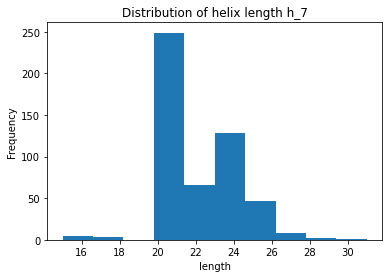

In [24]:
name = "h_7"
length = []
for z in helixPos[helixPos["hname"] == name]["sliced_Sequence"].tolist():
  length.append(len(z))

import matplotlib.pyplot as plt
plt.hist(length)                        

plt.title('Distribution of helix length '+name)          
plt.xlabel('length') # x軸のラベル
plt.ylabel('Frequency')                       
plt.savefig(name+"_length.png")
plt.show()  

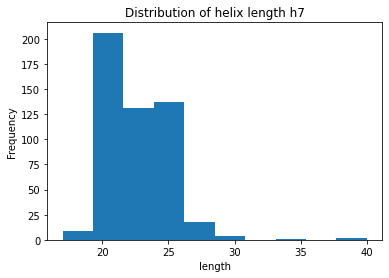